Árbol de decisión sin poda:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Árbol podado (max_depth=3, min_samples_split=5):
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



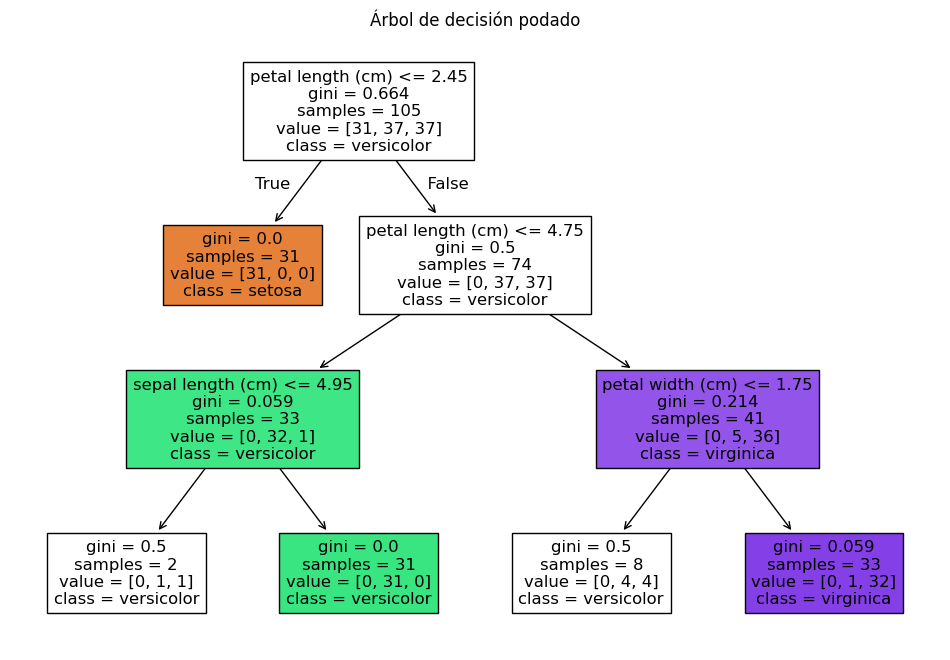

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

# Dividir el dataset en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Árbol sin poda (profundidad máxima por defecto = hasta que todas las hojas sean puras)
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_tree.fit(X_train, y_train)
y_pred_tree = modelo_tree.predict(X_test)

print("Árbol de decisión sin poda:")
print(classification_report(y_test, y_pred_tree, target_names=target_names))

# Cambio para aplicación: limitar la profundidad y el mínimo de muestras por hoja para evitar overfitting
modelo_podado = DecisionTreeClassifier(max_depth=3, min_samples_split=5, min_samples_leaf=2, random_state=42)
modelo_podado.fit(X_train, y_train)
y_pred_podado = modelo_podado.predict(X_test)

print("\nÁrbol podado (max_depth=3, min_samples_split=5):")
print(classification_report(y_test, y_pred_podado, target_names=target_names))

# Visualización del árbol (opcional)
plt.figure(figsize=(12,8))
tree.plot_tree(modelo_podado, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.title("Árbol de decisión podado")
plt.show()

## Carga y Preparación de Datos: Dataset Iris

Para esta demostración, utilizaremos el famoso dataset Iris, un conjunto de datos clásico en machine learning que contiene 150 muestras de tres especies diferentes de flores de Iris (setosa, versicolor, virginica), con cuatro características (largo y ancho del sépalo, y largo y ancho del pétalo). Este dataset es ideal para problemas de clasificación.

### Pasos:

1.  **Cargar el dataset**: `load_iris()` de `sklearn.datasets`.
2.  **Dividir en características (X) y objetivo (y)**.
3.  **Dividir en conjuntos de entrenamiento y prueba**: Utilizaremos `train_test_split` para separar los datos, lo que nos permite evaluar el rendimiento del modelo en datos no vistos.

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report

# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names
feature_names = iris.feature_names

# Dividir el dataset en conjuntos de entrenamiento y prueba
# test_size=0.3 indica que el 30% de los datos se usarán para prueba.
# random_state=42 asegura que la división sea la misma cada vez que se ejecute.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)} muestras")
print(f"Tamaño del conjunto de prueba: {len(X_test)} muestras")
print(f"Nombres de las características: {feature_names}")
print(f"Nombres de las clases objetivo: {target_names}")

Tamaño del conjunto de entrenamiento: 105 muestras
Tamaño del conjunto de prueba: 45 muestras
Nombres de las características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Nombres de las clases objetivo: ['setosa' 'versicolor' 'virginica']


## Árbol de Decisión sin Poda (Overfitting Potencial)

Un árbol de decisión sin poda crecerá hasta que cada nodo hoja represente una clase pura o hasta que no haya más características para dividir. Esto significa que el árbol aprende los datos de entrenamiento con mucha precisión, incluyendo el ruido. Aunque esto puede resultar en una alta precisión en el conjunto de entrenamiento, a menudo conduce a un **sobreajuste (overfitting)**, donde el modelo funciona mal con datos nuevos e invisibles. En aplicaciones reales, esto es un problema crítico.

Entrenaremos un `DecisionTreeClassifier` con los parámetros por defecto, lo que permite que el árbol crezca hasta su máxima profundidad.

In [3]:
# Árbol sin poda (profundidad máxima por defecto = hasta que todas las hojas sean puras)
# No se especifican restricciones de profundidad o tamaño mínimo de muestras.
modelo_tree = DecisionTreeClassifier(random_state=42)
modelo_tree.fit(X_train, y_train)
y_pred_tree = modelo_tree.predict(X_test)

print("### Árbol de decisión sin poda (parámetros por defecto): ###")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_tree, target_names=target_names))

### Árbol de decisión sin poda (parámetros por defecto): ###

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Árbol de Decisión Podado para Aplicación Real



In [4]:
# Cambio para aplicación: limitar la profundidad y el mínimo de muestras por hoja para evitar overfitting
# max_depth=3: El árbol no crecerá más allá de 3 niveles de profundidad.
# min_samples_split=5: Un nodo solo se dividirá si contiene 5 o más muestras.
# min_samples_leaf=2: Cada nodo hoja debe contener al menos 2 muestras.
modelo_podado = DecisionTreeClassifier(max_depth=3, min_samples_split=5, min_samples_leaf=2, random_state=42)
modelo_podado.fit(X_train, y_train)
y_pred_podado = modelo_podado.predict(X_test)

print("### Árbol podado (max_depth=3, min_samples_split=5, min_samples_leaf=2): ###")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_podado, target_names=target_names))

### Árbol podado (max_depth=3, min_samples_split=5, min_samples_leaf=2): ###

Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Visualización del Árbol de Decisión Podado

Visualizar el árbol es fundamental para entender cómo toma sus decisiones el modelo. Cada nodo muestra la característica utilizada para la división, el umbral de división, la impureza Gini del nodo, el número de muestras que llegan a ese nodo y la distribución de clases en ese nodo.

*   **`feature_names`**: Nombres de las características para una lectura más fácil.
*   **`class_names`**: Nombres de las clases objetivo.
*   **`filled=True`**: Colorea los nodos según la clase mayoritaria, lo que ayuda a visualizar el camino de clasificación.

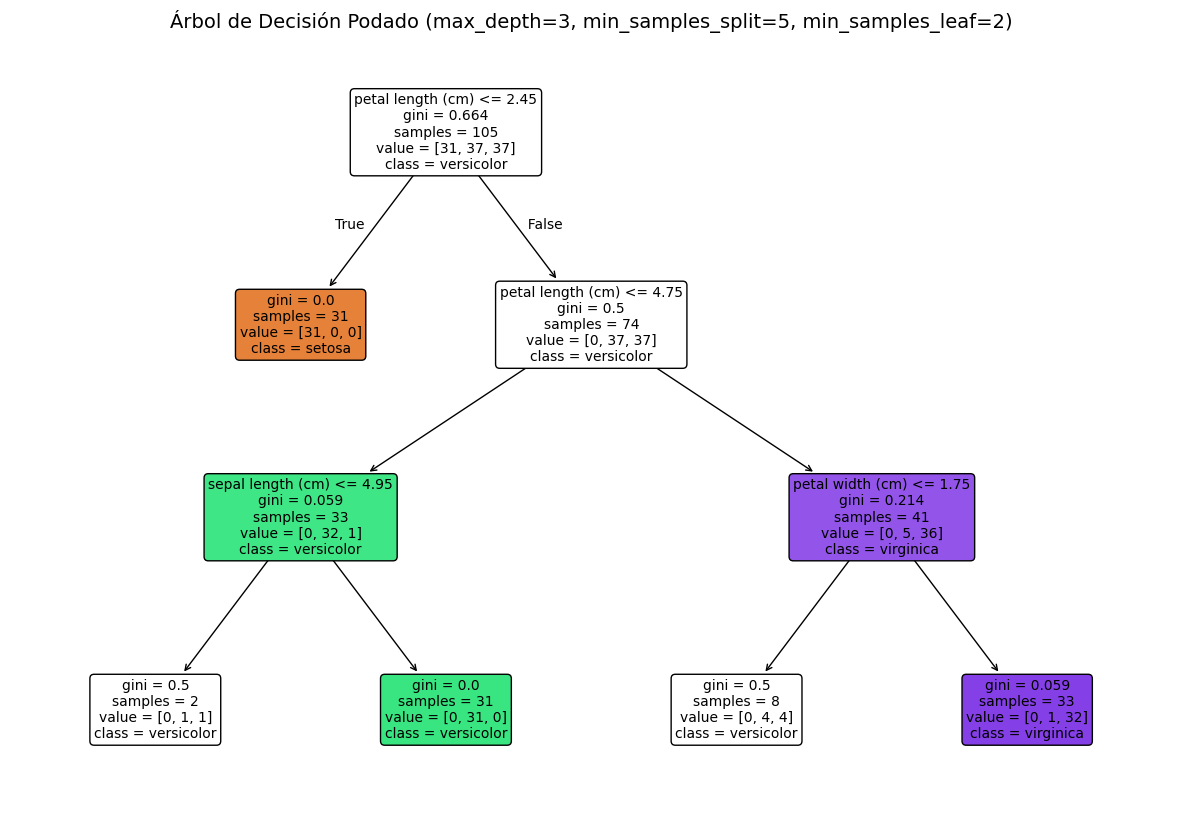

In [5]:
# Visualización del árbol podado
plt.figure(figsize=(15, 10)) # Aumentar el tamaño de la figura para mejor visibilidad
plot_tree(modelo_podado,
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10) # Ajustar el tamaño de la fuente para mejor legibilidad
plt.title("Árbol de Decisión Podado (max_depth=3, min_samples_split=5, min_samples_leaf=2)", fontsize=14)
plt.show()